In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
"""
pandas: used for loading, cleaning, transforming, and analyzing structured data with Dataframes and Series.

seaborn: High-level statistical data visualization library built on top of Matplotlib, for attractive and interactive plot.

matplotlib.pyplot: core plotting library in Python, for creating custom static, animated and interactive visualizations.

ipywidgets: Provides interactive UI controls (slider, dropdown, buttons) for jupyter notebooks to explore data dynamiclly.

scikitlearn (sklearn): Machine learning library offering tools for preprocessing, model building, evaluation and model selection.
"""


'\npandas: used for loading, cleaning, transforming, and analyzing structured data with Dataframes and Series.\n\nseaborn: High-level statistical data visualization library built on top of Matplotlib, for attractive and interactive plot.\n\nmatplotlib.pyplot: core plotting library in Python, for creating custom static, animated and interactive visualizations.\n\nipywidgets: Provides interactive UI controls (slider, dropdown, buttons) for jupyter notebooks to explore data dynamiclly.\n\nscikitlearn (sklearn): Machine learning library offering tools for preprocessing, model building, evaluation and model selection.\n'

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info() #for analyzing the data

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [5]:
df["availability"].value_counts() #which value appears how many times in that column

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

'\n1. the more dark it is the lessor the corr.\n2. we dont want to use the entire corr.\n3. we only keep the prominant one and remove the other, this help us to reduce the data and make the process easier.\n4. here we can see the lighter, the more corr.\n5. center is completly white because its the same corr.\n6. here we have taken corr of all numberical values.\n'

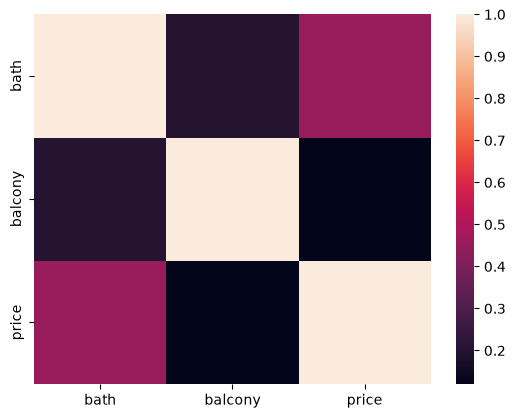

In [6]:
"""
Correlation: how much one column is depended on the other column.
### measures the strength and of the relationship between two variables in a dataset.

select_dtype(): selects based on the data types
"""

corr = df.select_dtypes("number").corr()
sns.heatmap(corr) #seaborn is a lib that help us create heatmaps

"""
1. the more dark it is the lessor the corr.
2. we dont want to use the entire corr.
3. we only keep the prominant one and remove the other, this help us to reduce the data and make the process easier.
4. here we can see the lighter, the more corr.
5. center is completly white because its the same corr.
6. here we have taken corr of all numberical values.
"""

In [7]:
"""
calculate null values
"""
df.isnull().sum()
#is null tells true or false, with .sum(), we added all the null values

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [8]:
df1 = df.drop(columns = ['area_type', 'society', 'balcony', 'availability'])
"""
df1 is a new dataframe as we dont want to delete columns from original dataframe.
"""

'\ndf1 is a new dataframe as we dont want to delete columns from original dataframe.\n'

In [9]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 520.4 KB


In [10]:
df1.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [11]:
"""
Droping null values
"""
df1.dropna(inplace = True)

In [12]:
df1.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [13]:
"""
to get the unique values of the column
"""
df['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',          nan,  '9 Bedroom',
     '27 BHK', '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',
     '16 BHK', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
     '13 BHK', '18 Bedroom']
Length: 32, dtype: str

In [14]:
df1['bedrooms'] = df1['size'].apply(lambda x: int(x.split(' ')[0]))

# .apply() -> a way of applying a function in that column.

In [15]:
df1.head()

,location,size,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [16]:
df1.info()

<class 'pandas.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  str    
 1   size        13246 non-null  str    
 2   total_sqft  13246 non-null  str    
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 724.4 KB


In [17]:
df1 = df1.drop(columns = ['size'])

In [18]:
df1.info()
df1.head()

<class 'pandas.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  str    
 1   total_sqft  13246 non-null  str    
 2   bath        13246 non-null  float64
 3   price       13246 non-null  float64
 4   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 620.9 KB


,location,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,1056,2.0,39.07,2
1,Chikka Tirupathi,2600,5.0,120.00,4
2,Uttarahalli,1440,2.0,62.00,3
3,Lingadheeranahalli,1521,3.0,95.00,3
4,Kothanur,1200,2.0,51.00,2


In [19]:
"""
We are doing to drop the values of the bedrooms which are very rare.
like, 40 bhk and etc.
these values are out lyers
"""
df1['bedrooms'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [20]:
df1[df1.bedrooms > 20]
#here we can see only 2 values.

,location,total_sqft,bath,price,bedrooms
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


In [21]:
"""
Now we will check what types of values in total square foot
total_sqft is a object
"""
df1['total_sqft'].unique()

<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '1379',        '3124',        '9200',         '613',         '250',
        '2395',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2067, dtype: str

In [22]:
#this fuction checks weather a value is converatble to float or not

def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [23]:
df1[~df1['total_sqft'].apply(is_float)].head(10)
#this line checks top 10 value that cannot be converted to float

,location,total_sqft,bath,price,bedrooms
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [24]:
def convert_sqrt_to_num(x):
  if isinstance(x, float): #isinstance, to do operations on the current hold value of x
    return x
  tokens = x.split('-')
  if len(tokens) == 2:
    return (float(tokens[0]) + float(tokens[1]))/2
  try:
    return float(x)
  except:
    return None

In [25]:
df4 = df1.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqrt_to_num)
df4.dropna(inplace = True)

In [26]:
df4.info()

<class 'pandas.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  str    
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 618.8 KB


In [27]:
df4.head()

,location,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb7ffe50>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb7b3090>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb7fd990>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb7b29d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb7b0150>],
 'means': []}

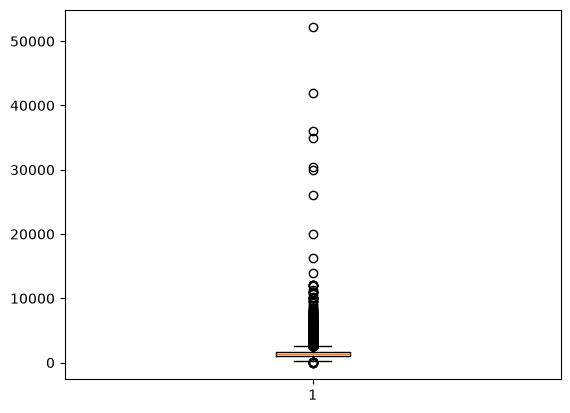

In [28]:
"""
Outliers: 1. finding the anomoly
1. they dont follow the general pattern of the data.
2. they can scew the data.
3. it can distort the stats.
4. we use IQR(inter quartile range) to remove them.
5. its important to remove to improve the quality of the model.

### BOX Plot:
1. wisker plot, use break our data into the quartile range.

Orange line inside the box → Median (50th percentile), the middle value of the data.
Box → Contains the middle 50% of the data (from Q1 to Q3).
Lower whisker → Smallest value that is not considered an outlier.
Upper whisker → Largest value that is not considered an outlier.
Circles above and below → Outliers (unusually large or small values).
"""
plt.boxplot(df4['total_sqft'])

In [29]:
df4['total_sqft'].describe()

count    13200.000000
mean      1555.302783
std       1237.323445
min          1.000000
25%       1100.000000
50%       1275.000000
75%       1672.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [30]:
"""
Now we have to create mask
"""
low, high = df4['total_sqft'].quantile([0.1, 0.9]) #taking 10 and 90 percent as the quartile
mask_area = df4['total_sqft'].between(low, high)
df4 = df4[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb896a90>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb744ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb866390>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb745210>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb746fd0>],
 'means': []}

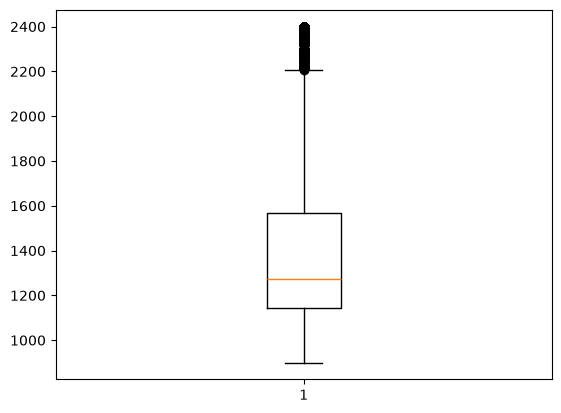

In [31]:
plt.boxplot(df4['total_sqft'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb892350>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb8910d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb892d10>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb893690>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb7edb90>],
 'means': []}

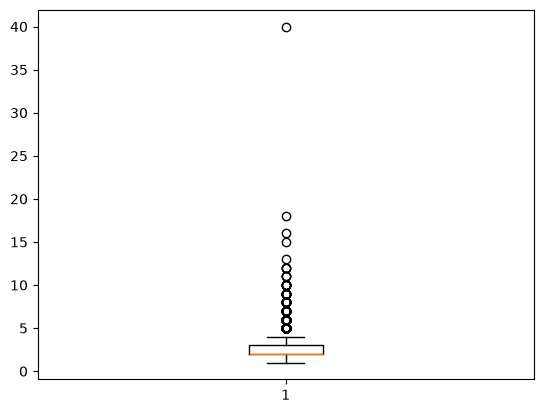

In [32]:
plt.boxplot(df4['bath'])
### Plotting for bathrooms

In [33]:
df4['bath'].describe()

count    10594.000000
mean         2.556069
std          1.088512
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         40.000000
Name: bath, dtype: float64

In [34]:
df4 = df4[df4['bath'] < 12]

{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb955250>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb9579d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb7b0d10>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb98c750>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb98e850>],
 'means': []}

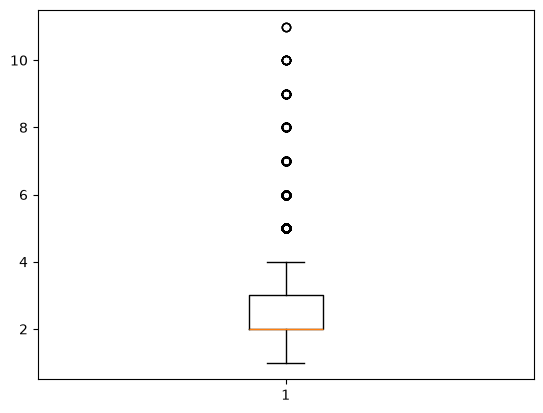

In [35]:
plt.boxplot(df4['bath'])

In [36]:
df4['bath'].value_counts()

bath
2.0     6468
3.0     2933
4.0      632
5.0      190
1.0      135
6.0      117
7.0       46
8.0       31
9.0       22
10.0       9
11.0       3
Name: count, dtype: int64

In [37]:
df4['price_per_sqft'] = df4['price'] * 100000 / df4['total_sqft']
#this line creates a new column that is dependent on the other column.

In [38]:
df4.head()

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,1170.0,2.0,38.00,2,3247.863248


In [39]:
df4['price_per_sqft'].describe()

count    10586.000000
mean      6244.315309
std       3698.326765
min        500.000000
25%       4206.709513
50%       5252.421226
75%       6761.335502
max      53150.000000
Name: price_per_sqft, dtype: float64

In [40]:
df4.info()

<class 'pandas.DataFrame'>
Index: 10586 entries, 0 to 13317
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        10586 non-null  str    
 1   total_sqft      10586 non-null  float64
 2   bath            10586 non-null  float64
 3   price           10586 non-null  float64
 4   bedrooms        10586 non-null  int64  
 5   price_per_sqft  10586 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 578.9 KB


{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb985650>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb9c7d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb985f50>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb9a76d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb9a4490>],
 'means': []}

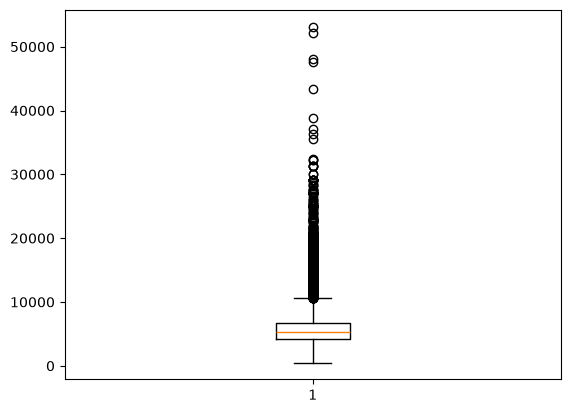

In [41]:
plt.boxplot(df4['price_per_sqft'])

In [42]:
low, high = df4['price_per_sqft'].quantile([0.1, 0.9])
mask_price = df4['price_per_sqft'].between(low, high)
df4 = df4[mask_price]

{'whiskers': [<matplotlib.lines.Line2D at 0x2b6fb98a610>,
 'caps': [<matplotlib.lines.Line2D at 0x2b6fb9b0d50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b6fb9ca310>],
 'medians': [<matplotlib.lines.Line2D at 0x2b6fb9ebb50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b6fb9e9d10>],
 'means': []}

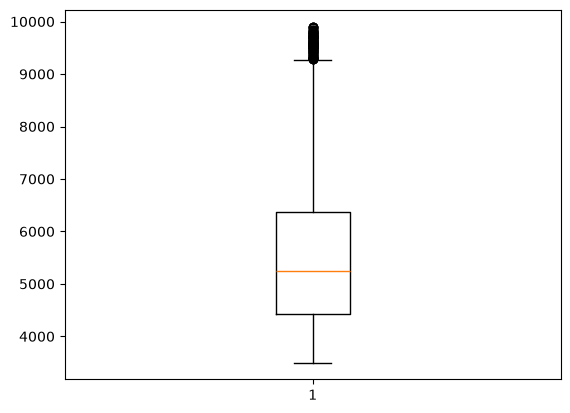

In [43]:
plt.boxplot(df4['price_per_sqft'])

In [44]:
"""
converting the string to computer level
"""
df4.location = df4.location.apply(lambda x: x.strip())
location_stats = df4['location'].value_counts(ascending = False)
location_stats #stores and display the data.

location
Whitefield                   355
Sarjapur  Road               293
Kanakpura Road               205
Thanisandra                  189
Electronic City              167
                            ... 
Kanakapur main road            1
Prasanna layout Herohalli      1
Hadosiddapura                  1
Sarvobhogam Nagar              1
Annaiah Reddy Layout           1
Name: count, Length: 934, dtype: int64

In [45]:
location_stats_less_than_10 =  location_stats[location_stats <= 10]
len(location_stats_less_than_10)

765

In [46]:
df4.location.nunique()
### nunique() -> number of unique values

934

In [47]:
df4.location = df4.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
df4.location.nunique()

170

In [48]:
df4.head()

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
8,Marathahalli,1310.0,3.0,63.25,3,4828.244275


In [49]:
df4 = df4.drop(columns = 'price_per_sqft')

In [50]:
df4.head()

,location,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
8,Marathahalli,1310.0,3.0,63.25,3


In [51]:
!pip install category_encoders

### the string columns are called categorial columns, so we need to convert them to binary

In [52]:
from category_encoders import OneHotEncoder
### One hot encoder -> this will create a new column for each string(unique values), so one hot encoder keeps 1 for the column where the value is present, that is true.

In [53]:
x = df4.drop(['price'], axis = 'columns')

In [54]:
y = df4.price

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 10)

### Now we have to split our data into test, train.

In [56]:
"""
pipeline is a structured sequence that chains preprocessing steps(scaling, encoding, feature selection)
important : it ensures that the same transformation is applied during training and prediction, reducing the risk of data leakage.
"""

### LINEAR REGRESSION: it is a supervised learning algo that models relationship between input features.

model = make_pipeline(OneHotEncoder(), LinearRegression())
model.fit(x_train, y_train)

C:\Users\nikhi\anaconda3\envs\housing_env\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('onehotencoder', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,"['lo...on', 'to...ft', 'bath', 'be...ms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,cols,['location']
,verbose,0
,drop_invariant,False
,return_df,True


In [57]:
"""
LINEAR REGRESSION: plots a best fit line, our goal is to minimize the error.
"""

'\nLINEAR REGRESSION: plots a best fit line, our goal is to minimize the error.\n'

In [58]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred) #computes average absolute difference between the test data and the predicted data.
mae

13.591634884070153

In [59]:
from sklearn.metrics import mean_absolute_percentage_error as mapefn

In [60]:
mape = mapefn(y_test, y_pred)
mape

0.176646962194763

In [61]:
def predict_price(input_data: dict):
  input_df = pd.DataFrame([input_data])
  return model.predict(input_df)[0]

example_house ={
    'location' : 'Whitefield',
    'total_sqft' : 1200,
    'bath' : 2,
    'bedrooms' : 2
}


print(predict_price(example_house))

62.99548916417392


In [62]:
import pickle

with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [63]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [66]:
print(df4.columns)
locations = sorted(df4['location'].unique().tolist())

print(locations[:20])

Index(['location', 'total_sqft', 'bath', 'price', 'bedrooms'], dtype='str')
['1st Phase JP Nagar', '5th Phase JP Nagar', '6th Phase JP Nagar', '7th Phase JP Nagar', '8th Phase JP Nagar', '9th Phase JP Nagar', 'AECS Layout', 'Abbigere', 'Akshaya Nagar', 'Ambalipura', 'Ambedkar Nagar', 'Amruthahalli', 'Anandapura', 'Ardendale', 'Arekere', 'BEML Layout', 'BTM 2nd Stage', 'BTM Layout', 'Babusapalaya', 'Badavala Nagar']
